# Data Dynamo – Day 1

## Hourly Regional Power Consumption Forecasting

### Problem Statement
Forecast hourly regional power consumption using time-series models, and build a natural-language query interface for grid operators to query power telemetry data.

### Day 1 Objective
Develop the initial power-consumption forecasting model and define the natural-language telemetry workflow.

### Team
Team 4 – Data Dynamo

In [68]:
def forecast_query(query):
    intent = identify_intent(query)
    region = extract_region(query)

    if intent != "POWER_FORECAST":
        return "Please ask a power forecast query."

    if region is None:
        return "Please specify a region."

    region_results = results[
        results["region"] == region
    ]

    if region_results.empty:
        return f"No forecast data available for {region}."

    latest_prediction = region_results.iloc[-1]

    return (
        f"Forecasted power consumption for {region} is "
        f"{latest_prediction['predicted_power_mw']:.2f} MW."
    )

In [69]:
queries = [
    "What is the power forecast for Region A?",
    "What is the power forecast for Region B?",
    "Predict power consumption for Region C"
]

for query in queries:
    print("Query:", query)
    print("Response:", forecast_query(query))
    print("-" * 60)

Query: What is the power forecast for Region A?
Response: No forecast data available for Region A.
------------------------------------------------------------
Query: What is the power forecast for Region B?
Response: No forecast data available for Region B.
------------------------------------------------------------
Query: Predict power consumption for Region C
Response: Forecasted power consumption for Region C is 456.40 MW.
------------------------------------------------------------


In [70]:
test_queries = [
    "Forecast power consumption for Region A",
    "Predict the power for Region B",
    "What will the power consumption be in Region C?",
    "Give me the forecast for Region A",
    "Can you predict power consumption for Region B?"
]

for query in test_queries:
    print("Query:", query)
    print("Intent:", identify_intent(query))
    print("Region:", extract_region(query))
    print("Response:", forecast_query(query))
    print("-" * 70)

Query: Forecast power consumption for Region A
Intent: POWER_FORECAST
Region: Region A
Response: No forecast data available for Region A.
----------------------------------------------------------------------
Query: Predict the power for Region B
Intent: POWER_FORECAST
Region: Region B
Response: No forecast data available for Region B.
----------------------------------------------------------------------
Query: What will the power consumption be in Region C?
Intent: POWER_USAGE
Region: Region C
Response: Please ask a power forecast query.
----------------------------------------------------------------------
Query: Give me the forecast for Region A
Intent: POWER_FORECAST
Region: Region A
Response: No forecast data available for Region A.
----------------------------------------------------------------------
Query: Can you predict power consumption for Region B?
Intent: POWER_FORECAST
Region: Region B
Response: No forecast data available for Region B.
----------------------------------

In [71]:
query = "What is the power forecast?"

print("Query:", query)
print("Response:", forecast_query(query))

Query: What is the power forecast?
Response: Please specify a region.


In [72]:
query = "What is the temperature in Region A?"

print("Query:", query)
print("Response:", forecast_query(query))

Query: What is the temperature in Region A?
Response: Please ask a power forecast query.


In [73]:
query = input("Enter your power forecast query: ")

response = forecast_query(query)

print("\nGrid Assistant Response:")
print(response)

Enter your power forecast query: What is the power forecast for Region A?

Grid Assistant Response:
No forecast data available for Region A.


In [74]:
def grid_assistant(query):
    intent = identify_intent(query)
    region = extract_region(query)

    print("User Query:", query)
    print("Detected Intent:", intent)
    print("Detected Region:", region)

    if region is None:
        return "Please specify a region such as Region A, Region B, or Region C."

    if intent == "POWER_FORECAST":

        region_results = results[
            results["region"] == region
        ]

        if region_results.empty:
            return f"No forecast data available for {region}."

        latest_prediction = region_results.iloc[-1]

        return (
            f"The forecasted power consumption for {region} is "
            f"{latest_prediction['predicted_power_mw']:.2f} MW."
        )

    elif intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"The latest power consumption in {region} is "
            f"{latest['power_mw']:.2f} MW."
        )

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"The latest temperature in {region} is "
            f"{latest['temperature']:.2f} °C."
        )

    else:
        return "Sorry, I could not understand the query."

# Day 3 – Forecast and Query Integration Enhancement

## Objective

Enhance the connection between the power forecasting model and the natural-language telemetry interface.

## Day 3 Tasks

- Improve natural-language query processing.
- Connect different query types with telemetry results.
- Handle forecast, power consumption, and temperature queries.
- Provide structured responses for grid operators.
- Test the integrated query workflow.

In [105]:
def process_grid_query(query):

    intent = identify_intent(query)
    region = extract_region(query)

    if region is None:
        return {
            "query": query,
            "intent": intent,
            "region": None,
            "response": "Please specify a region such as Region A, Region B, or Region C."
        }

    if intent == "POWER_FORECAST":

        region_results = results[
            results["region"] == region
        ]

        if region_results.empty:
            response = f"No forecast data available for {region}."
        else:
            latest_prediction = region_results.iloc[-1]

            response = (
                f"The forecasted power consumption for {region} is "
                f"{latest_prediction['predicted_power_mw']:.2f} MW."
            )

    elif intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"The latest power consumption in {region} is "
            f"{latest['power_mw']:.2f} MW."
        )

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"The latest temperature in {region} is "
            f"{latest['temperature']:.2f} °C."
        )

    else:
        response = "Sorry, I could not understand the query."

    return {
        "query": query,
        "intent": intent,
        "region": region,
        "response": response
    }

In [106]:
day3_queries = [
    "What is the power forecast for Region A?",
    "What is the power consumption in Region B?",
    "What is the temperature in Region C?",
    "Predict power consumption for Region A"
]

for query in day3_queries:

    result = process_grid_query(query)

    print("Query:", result["query"])
    print("Intent:", result["intent"])
    print("Region:", result["region"])
    print("Response:", result["response"])
    print("-" * 70)

Query: What is the power forecast for Region A?
Intent: POWER_FORECAST
Region: Region A
Response: No forecast data available for Region A.
----------------------------------------------------------------------
Query: What is the power consumption in Region B?
Intent: POWER_USAGE
Region: Region B
Response: The latest power consumption in Region B is 657.41 MW.
----------------------------------------------------------------------
Query: What is the temperature in Region C?
Intent: TEMPERATURE
Region: Region C
Response: The latest temperature in Region C is 20.40 °C.
----------------------------------------------------------------------
Query: Predict power consumption for Region A
Intent: POWER_FORECAST
Region: Region A
Response: No forecast data available for Region A.
----------------------------------------------------------------------


In [107]:
query = "What is the power forecast?"

result = process_grid_query(query)

print("Query:", result["query"])
print("Intent:", result["intent"])
print("Region:", result["region"])
print("Response:", result["response"])

Query: What is the power forecast?
Intent: POWER_FORECAST
Region: None
Response: Please specify a region such as Region A, Region B, or Region C.


In [108]:
day3_results = []

for query in day3_queries:

    result = process_grid_query(query)

    day3_results.append({
        "Query": result["query"],
        "Intent": result["intent"],
        "Region": result["region"],
        "Response": result["response"]
    })

day3_results_df = pd.DataFrame(day3_results)

day3_results_df

,Query,Intent,Region,Response
0,What is the power forecast for Region A?,POWER_FORECAST,Region A,No forecast data available for Region A.
1,What is the power consumption in Region B?,POWER_USAGE,Region B,The latest power consumption in Region B is 65...
2,What is the temperature in Region C?,TEMPERATURE,Region C,The latest temperature in Region C is 20.40 °C.
3,Predict power consumption for Region A,POWER_FORECAST,Region A,No forecast data available for Region A.


In [109]:
final_day3_queries = [
    "What is the power forecast for Region A?",
    "Predict power consumption for Region B",
    "What is the power consumption in Region C?",
    "What is the temperature in Region A?",
    "What is the power forecast?"
]

for query in final_day3_queries:

    result = process_grid_query(query)

    print("User Query:", result["query"])
    print("Detected Intent:", result["intent"])
    print("Detected Region:", result["region"])
    print("Assistant Response:", result["response"])
    print("=" * 80)

User Query: What is the power forecast for Region A?
Detected Intent: POWER_FORECAST
Detected Region: Region A
Assistant Response: No forecast data available for Region A.
User Query: Predict power consumption for Region B
Detected Intent: POWER_FORECAST
Detected Region: Region B
Assistant Response: No forecast data available for Region B.
User Query: What is the power consumption in Region C?
Detected Intent: POWER_USAGE
Detected Region: Region C
Assistant Response: The latest power consumption in Region C is 418.56 MW.
User Query: What is the temperature in Region A?
Detected Intent: TEMPERATURE
Detected Region: Region A
Assistant Response: The latest temperature in Region A is 22.00 °C.
User Query: What is the power forecast?
Detected Intent: POWER_FORECAST
Detected Region: None
Assistant Response: Please specify a region such as Region A, Region B, or Region C.


# Day 3 Summary

## Completed Tasks

- Enhanced the natural-language query processing workflow.
- Connected forecast queries with forecasting results.
- Connected power-consumption queries with telemetry data.
- Connected temperature queries with telemetry data.
- Added region identification.
- Added structured query-response output.
- Added query validation testing.
- Tested queries with different natural-language formats.
- Added handling for queries where the region is missing.

## Day 3 Outcome

The integrated grid assistant can identify the user's query intent and requested region, retrieve the relevant power or forecast information, and generate a structured natural-language response.

## Status

**Day 3- Completed**

# Day 4 – Grid Telemetry Documentation and Metadata

## Objective

Prepare documentation and metadata for the regional power telemetry data so that the natural-language assistant can understand the available data and fields.

## Day 4 Tasks

- Document the telemetry dataset.
- Describe each telemetry field.
- Define region information.
- Define units and meanings of measurements.
- Create metadata for retrieval.
- Prepare the data dictionary for future natural-language queries.

In [110]:
telemetry_metadata = pd.DataFrame({
    "Field": [
        "timestamp",
        "region",
        "temperature",
        "base_load",
        "power_mw",
        "hour",
        "day_of_week",
        "day_of_month",
        "month",
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_24"
    ],

    "Description": [
        "Date and time of the power telemetry measurement",
        "Regional identifier",
        "Temperature recorded for the telemetry period",
        "Base power load assigned to the region",
        "Regional power consumption",
        "Hour of the day",
        "Day of the week",
        "Day of the month",
        "Month of the year",
        "Power consumption from the previous hour",
        "Power consumption from two hours earlier",
        "Power consumption from three hours earlier",
        "24-hour rolling average of power consumption"
    ],

    "Unit": [
        "datetime",
        "text",
        "°C",
        "MW",
        "MW",
        "0-23",
        "0-6",
        "1-31",
        "1-12",
        "MW",
        "MW",
        "MW",
        "MW"
    ],

    "Data_Type": [
        "datetime",
        "string",
        "float",
        "integer",
        "float",
        "integer",
        "integer",
        "integer",
        "integer",
        "float",
        "float",
        "float",
        "float"
    ]
})

telemetry_metadata

,Field,Description,Unit,Data_Type
0,timestamp,Date and time of the power telemetry measurement,datetime,datetime
1,region,Regional identifier,text,string
2,temperature,Temperature recorded for the telemetry period,°C,float
3,base_load,Base power load assigned to the region,MW,integer
4,power_mw,Regional power consumption,MW,float
5,hour,Hour of the day,0-23,integer
6,day_of_week,Day of the week,0-6,integer
7,day_of_month,Day of the month,1-31,integer
8,month,Month of the year,1-12,integer
9,lag_1,Power consumption from the previous hour,MW,float


In [111]:
region_metadata = pd.DataFrame({
    "Region": [
        "Region A",
        "Region B",
        "Region C"
    ],

    "Base_Load_MW": [
        400,
        550,
        300
    ],

    "Description": [
        "Regional power consumption area A",
        "Regional power consumption area B",
        "Regional power consumption area C"
    ]
})

region_metadata

,Region,Base_Load_MW,Description
0,Region A,400,Regional power consumption area A
1,Region B,550,Regional power consumption area B
2,Region C,300,Regional power consumption area C


In [112]:
telemetry_documentation = f"""
GRID TELEMETRY DATA DOCUMENTATION

Project: Data Dynamo
Purpose: Regional power consumption forecasting and natural-language telemetry queries.

AVAILABLE REGIONS
"""

for _, row in region_metadata.iterrows():
    telemetry_documentation += f"""
- {row['Region']}
  Base Load: {row['Base_Load_MW']} MW
  Description: {row['Description']}
"""

telemetry_documentation += """

TELEMETRY FIELDS
"""

for _, row in telemetry_metadata.iterrows():
    telemetry_documentation += f"""
- Field: {row['Field']}
  Description: {row['Description']}
  Unit: {row['Unit']}
  Data Type: {row['Data_Type']}
"""

print(telemetry_documentation)


GRID TELEMETRY DATA DOCUMENTATION

Project: Data Dynamo
Purpose: Regional power consumption forecasting and natural-language telemetry queries.

AVAILABLE REGIONS

- Region A
  Base Load: 400 MW
  Description: Regional power consumption area A

- Region B
  Base Load: 550 MW
  Description: Regional power consumption area B

- Region C
  Base Load: 300 MW
  Description: Regional power consumption area C


TELEMETRY FIELDS

- Field: timestamp
  Description: Date and time of the power telemetry measurement
  Unit: datetime
  Data Type: datetime

- Field: region
  Description: Regional identifier
  Unit: text
  Data Type: string

- Field: temperature
  Description: Temperature recorded for the telemetry period
  Unit: °C
  Data Type: float

- Field: base_load
  Description: Base power load assigned to the region
  Unit: MW
  Data Type: integer

- Field: power_mw
  Description: Regional power consumption
  Unit: MW
  Data Type: float

- Field: hour
  Description: Hour of the day
  Unit: 0-

In [114]:
with open("telemetry_documentation.txt", "w", encoding="utf-8") as file:
    file.write(telemetry_documentation)

print("Telemetry documentation created successfully!")

Telemetry documentation created successfully!


In [115]:
import os

print("File exists:", os.path.exists("telemetry_documentation.txt"))
print("File size:", os.path.getsize("telemetry_documentation.txt"), "bytes")

File exists: True
File size: 1702 bytes


# Day 4 Summary

## Completed Tasks

- Documented the regional power telemetry dataset.
- Created a telemetry data dictionary.
- Defined field descriptions and units.
- Created region metadata for Region A, Region B, and Region C.
- Generated retrieval-ready telemetry documentation.
- Saved the documentation as `telemetry_documentation.txt`.

## Day 4 Outcome

The telemetry dataset is now documented with field-level metadata, region information, units, and descriptions. The documentation can be used as a reference for future natural-language query and retrieval tasks.

## Status

**Day 4 -  Completed**

# Day 5 – Prompt Design for Telemetry Queries

## Objective

Design prompts that help the natural-language grid assistant understand telemetry queries and provide clear explanations of power forecasts.

## Day 5 Tasks

- Design prompts for power telemetry queries.
- Design prompts for temperature queries.
- Design prompts for power forecast queries.
- Create instructions for identifying the region.
- Create instructions for generating clear forecast explanations.
- Test the designed prompts with sample operator queries.

In [116]:
telemetry_prompt = """
You are a grid telemetry assistant.

Understand the user's query and identify:
1. The type of information requested.
2. The region mentioned in the query.
3. The required telemetry field.

Supported information:
- Power consumption
- Temperature
- Power forecast

Available regions:
- Region A
- Region B
- Region C

Respond clearly and briefly for a grid operator.
"""

forecast_prompt = """
You are a power forecasting assistant.

When the user asks about a power forecast:
1. Identify the requested region.
2. Retrieve the corresponding forecast result.
3. Report the predicted power consumption in MW.
4. Give a clear and simple explanation.

If the region is missing, ask the user to specify Region A,
Region B, or Region C.
"""

print("Telemetry Prompt:")
print(telemetry_prompt)

print("\nForecast Prompt:")
print(forecast_prompt)

Telemetry Prompt:

You are a grid telemetry assistant.

Understand the user's query and identify:
1. The type of information requested.
2. The region mentioned in the query.
3. The required telemetry field.

Supported information:
- Power consumption
- Temperature
- Power forecast

Available regions:
- Region A
- Region B
- Region C

Respond clearly and briefly for a grid operator.


Forecast Prompt:

You are a power forecasting assistant.

When the user asks about a power forecast:
1. Identify the requested region.
2. Retrieve the corresponding forecast result.
3. Report the predicted power consumption in MW.
4. Give a clear and simple explanation.

If the region is missing, ask the user to specify Region A,
Region B, or Region C.



In [117]:
def prompt_query_analysis(query):

    intent = identify_intent(query)
    region = extract_region(query)

    if region is None:
        region_status = "Region not specified"
    else:
        region_status = region

    return {
        "query": query,
        "intent": intent,
        "region": region_status
    }


test_queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "What is the power forecast for Region C?",
    "Predict power consumption for Region A",
    "What is the power forecast?"
]

for query in test_queries:

    analysis = prompt_query_analysis(query)

    print("User Query:", analysis["query"])
    print("Detected Intent:", analysis["intent"])
    print("Detected Region:", analysis["region"])
    print("-" * 70)

User Query: What is the power consumption in Region A?
Detected Intent: POWER_USAGE
Detected Region: Region A
----------------------------------------------------------------------
User Query: What is the temperature in Region B?
Detected Intent: TEMPERATURE
Detected Region: Region B
----------------------------------------------------------------------
User Query: What is the power forecast for Region C?
Detected Intent: POWER_FORECAST
Detected Region: Region C
----------------------------------------------------------------------
User Query: Predict power consumption for Region A
Detected Intent: POWER_FORECAST
Detected Region: Region A
----------------------------------------------------------------------
User Query: What is the power forecast?
Detected Intent: POWER_FORECAST
Detected Region: Region not specified
----------------------------------------------------------------------


In [118]:
def generate_forecast_explanation(region):

    region_results = results[
        results["region"] == region
    ]

    if region_results.empty:
        return f"No forecast data available for {region}."

    latest_prediction = region_results.iloc[-1]

    predicted_power = latest_prediction["predicted_power_mw"]

    explanation = (
        f"The forecasted power consumption for {region} is "
        f"{predicted_power:.2f} MW. "
        f"This forecast is based on historical power consumption, "
        f"temperature, time-based features, lag values, "
        f"and the 24-hour rolling average."
    )

    return explanation


print(generate_forecast_explanation("Region A"))

No forecast data available for Region A.


In [119]:
for region in regions:
    print("Region:", region)
    print(generate_forecast_explanation(region))
    print("-" * 70)

Region: Region A
No forecast data available for Region A.
----------------------------------------------------------------------
Region: Region B
No forecast data available for Region B.
----------------------------------------------------------------------
Region: Region C
The forecasted power consumption for Region C is 456.40 MW. This forecast is based on historical power consumption, temperature, time-based features, lag values, and the 24-hour rolling average.
----------------------------------------------------------------------


In [120]:
def day5_grid_assistant(query):

    analysis = prompt_query_analysis(query)

    intent = analysis["intent"]
    region = analysis["region"]

    if region == "Region not specified":
        return "Please specify a region such as Region A, Region B, or Region C."

    if intent == "POWER_FORECAST":
        return generate_forecast_explanation(region)

    elif intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"The latest power consumption in {region} is "
            f"{latest['power_mw']:.2f} MW."
        )

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"The latest temperature in {region} is "
            f"{latest['temperature']:.2f} °C."
        )

    else:
        return "Sorry, I could not understand the query."

In [121]:
day5_queries = [
    "What is the power forecast for Region A?",
    "Can you predict power consumption for Region B?",
    "What is the power consumption in Region C?",
    "What is the temperature in Region A?",
    "What is the power forecast?"
]

for query in day5_queries:

    print("User Query:", query)
    print("Assistant Response:")
    print(day5_grid_assistant(query))
    print("=" * 80)

User Query: What is the power forecast for Region A?
Assistant Response:
No forecast data available for Region A.
User Query: Can you predict power consumption for Region B?
Assistant Response:
No forecast data available for Region B.
User Query: What is the power consumption in Region C?
Assistant Response:
The latest power consumption in Region C is 418.56 MW.
User Query: What is the temperature in Region A?
Assistant Response:
The latest temperature in Region A is 22.00 °C.
User Query: What is the power forecast?
Assistant Response:
Please specify a region such as Region A, Region B, or Region C.


In [122]:
evaluation_cases = [
    {
        "query": "What is the power forecast for Region A?",
        "expected_intent": "POWER_FORECAST",
        "expected_region": "Region A"
    },
    {
        "query": "Predict power consumption for Region B",
        "expected_intent": "POWER_FORECAST",
        "expected_region": "Region B"
    },
    {
        "query": "What is the power consumption in Region C?",
        "expected_intent": "POWER_USAGE",
        "expected_region": "Region C"
    },
    {
        "query": "What is the temperature in Region A?",
        "expected_intent": "TEMPERATURE",
        "expected_region": "Region A"
    }
]

correct = 0

for case in evaluation_cases:

    analysis = prompt_query_analysis(case["query"])

    intent_correct = (
        analysis["intent"] == case["expected_intent"]
    )

    region_correct = (
        analysis["region"] == case["expected_region"]
    )

    if intent_correct and region_correct:
        correct += 1

    print("Query:", case["query"])
    print("Expected Intent:", case["expected_intent"])
    print("Detected Intent:", analysis["intent"])
    print("Expected Region:", case["expected_region"])
    print("Detected Region:", analysis["region"])
    print("-" * 70)


accuracy = (correct / len(evaluation_cases)) * 100

print("Day 5 Prompt Evaluation")
print("----------------------------")
print("Total Test Cases:", len(evaluation_cases))
print("Correct Cases:", correct)
print(f"Prompt Query Understanding Accuracy: {accuracy:.2f}%")

Query: What is the power forecast for Region A?
Expected Intent: POWER_FORECAST
Detected Intent: POWER_FORECAST
Expected Region: Region A
Detected Region: Region A
----------------------------------------------------------------------
Query: Predict power consumption for Region B
Expected Intent: POWER_FORECAST
Detected Intent: POWER_FORECAST
Expected Region: Region B
Detected Region: Region B
----------------------------------------------------------------------
Query: What is the power consumption in Region C?
Expected Intent: POWER_USAGE
Detected Intent: POWER_USAGE
Expected Region: Region C
Detected Region: Region C
----------------------------------------------------------------------
Query: What is the temperature in Region A?
Expected Intent: TEMPERATURE
Detected Intent: TEMPERATURE
Expected Region: Region A
Detected Region: Region A
----------------------------------------------------------------------
Day 5 Prompt Evaluation
----------------------------
Total Test Cases: 4
Cor

In [123]:
prompt_documentation = """
DATA DYNAMO – DAY 5 PROMPT DOCUMENTATION

Purpose:
Design prompts for telemetry queries and forecast explanations.

1. TELEMETRY QUERY PROMPT

The assistant should:
- Understand the user's telemetry query.
- Identify the requested information.
- Identify the region.
- Identify the required telemetry field.
- Provide a clear response for the grid operator.

Supported queries:
- Power consumption
- Temperature
- Power forecast

Available regions:
- Region A
- Region B
- Region C


2. FORECAST EXPLANATION PROMPT

The assistant should:
- Identify the requested region.
- Retrieve the forecast result.
- Report predicted power consumption in MW.
- Explain that the forecast uses historical telemetry,
  temperature, time-based features, lag values,
  and rolling-average information.
- Ask for the region if it is missing.


3. DAY 5 TESTING

The prompt design was tested using multiple
natural-language grid operator queries.

The system evaluates:
- Query intent
- Region identification
- Forecast response generation
- Missing-region handling
"""

print(prompt_documentation)


DATA DYNAMO – DAY 5 PROMPT DOCUMENTATION

Purpose:
Design prompts for telemetry queries and forecast explanations.

1. TELEMETRY QUERY PROMPT

The assistant should:
- Understand the user's telemetry query.
- Identify the requested information.
- Identify the region.
- Identify the required telemetry field.
- Provide a clear response for the grid operator.

Supported queries:
- Power consumption
- Temperature
- Power forecast

Available regions:
- Region A
- Region B
- Region C


2. FORECAST EXPLANATION PROMPT

The assistant should:
- Identify the requested region.
- Retrieve the forecast result.
- Report predicted power consumption in MW.
- Explain that the forecast uses historical telemetry,
  temperature, time-based features, lag values,
  and rolling-average information.
- Ask for the region if it is missing.


3. DAY 5 TESTING

The prompt design was tested using multiple
natural-language grid operator queries.

The system evaluates:
- Query intent
- Region identification
- Forecas

In [124]:
with open("day5_prompt_documentation.txt", "w", encoding="utf-8") as file:
    file.write(prompt_documentation)

print("Day 5 prompt documentation saved successfully!")

Day 5 prompt documentation saved successfully!


In [125]:
import os

print(
    "File exists:",
    os.path.exists("day5_prompt_documentation.txt")
)

print(
    "File size:",
    os.path.getsize("day5_prompt_documentation.txt"),
    "bytes"
)

File exists: True
File size: 1050 bytes


# Day 5 Summary

## Completed Tasks

- Designed prompts for telemetry queries.
- Designed prompts for power forecast queries.
- Created instructions for identifying regions.
- Created forecast explanation instructions.
- Developed a prompt-based query analysis system.
- Tested different natural-language operator queries.
- Created forecast explanations using telemetry features.
- Evaluated query understanding accuracy.
- Created Day 5 prompt documentation.

## Day 5 Outcome

The project now has structured prompts for understanding grid telemetry queries and explaining power forecast results. The prompt design will be used as the foundation for developing the working natural-language grid assistant.

## Status

**Day 5 - Completed**

# Day 6 - Working Natural-Language Grid Assistant

## Objective

Develop a working natural-language grid assistant that can understand operator queries and provide telemetry and forecast information.

## Day 6 Tasks

- Develop the grid assistant.
- Process natural-language operator queries.
- Identify query intent.
- Identify the requested region.
- Retrieve telemetry information.
- Retrieve power forecast information.
- Generate clear natural-language responses.
- Test the working assistant with different queries.

In [126]:
def working_grid_assistant(query):

    intent = identify_intent(query)
    region = extract_region(query)

    if region is None:
        return {
            "query": query,
            "intent": intent,
            "region": None,
            "response": (
                "Please specify a region such as "
                "Region A, Region B, or Region C."
            )
        }

    if intent == "POWER_FORECAST":

        region_results = results[
            results["region"] == region
        ]

        if region_results.empty:
            response = f"No forecast data available for {region}."
        else:
            latest_prediction = region_results.iloc[-1]

            response = (
                f"The forecasted power consumption for {region} "
                f"is {latest_prediction['predicted_power_mw']:.2f} MW."
            )

    elif intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"The latest power consumption in {region} is "
            f"{latest['power_mw']:.2f} MW."
        )

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"The latest temperature in {region} is "
            f"{latest['temperature']:.2f} °C."
        )

    else:

        response = (
            "Sorry, I could not understand the query. "
            "You can ask about power consumption, temperature, "
            "or power forecast."
        )

    return {
        "query": query,
        "intent": intent,
        "region": region,
        "response": response
    }


print("Working Grid Assistant created successfully!")

Working Grid Assistant created successfully!


In [127]:
query = "What is the power forecast for Region A?"

result = working_grid_assistant(query)

print("User Query:", result["query"])
print("Detected Intent:", result["intent"])
print("Detected Region:", result["region"])
print("Assistant Response:", result["response"])

User Query: What is the power forecast for Region A?
Detected Intent: POWER_FORECAST
Detected Region: Region A
Assistant Response: No forecast data available for Region A.


In [128]:
day6_queries = [
    "What is the power forecast for Region A?",
    "What is the power consumption in Region B?",
    "What is the temperature in Region C?",
    "Predict power consumption for Region A",
    "Give me the forecast for Region B"
]

for query in day6_queries:

    result = working_grid_assistant(query)

    print("User Query:", result["query"])
    print("Intent:", result["intent"])
    print("Region:", result["region"])
    print("Assistant Response:", result["response"])
    print("=" * 80)

User Query: What is the power forecast for Region A?
Intent: POWER_FORECAST
Region: Region A
Assistant Response: No forecast data available for Region A.
User Query: What is the power consumption in Region B?
Intent: POWER_USAGE
Region: Region B
Assistant Response: The latest power consumption in Region B is 657.41 MW.
User Query: What is the temperature in Region C?
Intent: TEMPERATURE
Region: Region C
Assistant Response: The latest temperature in Region C is 20.40 °C.
User Query: Predict power consumption for Region A
Intent: POWER_FORECAST
Region: Region A
Assistant Response: No forecast data available for Region A.
User Query: Give me the forecast for Region B
Intent: POWER_FORECAST
Region: Region B
Assistant Response: No forecast data available for Region B.


In [129]:
query = "What is the power forecast?"

result = working_grid_assistant(query)

print("User Query:", result["query"])
print("Intent:", result["intent"])
print("Region:", result["region"])
print("Assistant Response:", result["response"])

User Query: What is the power forecast?
Intent: POWER_FORECAST
Region: None
Assistant Response: Please specify a region such as Region A, Region B, or Region C.


In [130]:
query = "Show me the grid status"

result = working_grid_assistant(query)

print("User Query:", result["query"])
print("Intent:", result["intent"])
print("Region:", result["region"])
print("Assistant Response:", result["response"])

User Query: Show me the grid status
Intent: UNKNOWN
Region: None
Assistant Response: Please specify a region such as Region A, Region B, or Region C.


In [131]:
query = input("Enter your grid query: ")

result = working_grid_assistant(query)

print("\n--- Grid Assistant ---")
print("User Query:", result["query"])
print("Detected Intent:", result["intent"])
print("Detected Region:", result["region"])
print("Assistant Response:", result["response"])

Enter your grid query: What is the power forecast for Region A?

--- Grid Assistant ---
User Query: What is the power forecast for Region A?
Detected Intent: POWER_FORECAST
Detected Region: Region A
Assistant Response: No forecast data available for Region A.


In [132]:
print("Grid Assistant Started")
print("Type 'exit' to stop the assistant.")

while True:

    query = input("\nOperator: ")

    if query.lower() == "exit":
        print("Grid Assistant: Session ended.")
        break

    result = working_grid_assistant(query)

    print("Grid Assistant:", result["response"])

Grid Assistant Started
Type 'exit' to stop the assistant.

Operator: Operator: What is the power forecast for Region A?  Grid Assistant: The forecasted power consumption for Region A is ...
Grid Assistant: No forecast data available for Region A.

Operator: exit
Grid Assistant: Session ended.


In [133]:
day6_test_cases = [
    ("What is the power forecast for Region A?", "POWER_FORECAST", "Region A"),
    ("Predict power consumption for Region B", "POWER_FORECAST", "Region B"),
    ("What is the power consumption in Region C?", "POWER_USAGE", "Region C"),
    ("What is the temperature in Region A?", "TEMPERATURE", "Region A")
]

correct = 0

for query, expected_intent, expected_region in day6_test_cases:

    result = working_grid_assistant(query)

    intent_match = result["intent"] == expected_intent
    region_match = result["region"] == expected_region

    if intent_match and region_match:
        correct += 1

    print("Query:", query)
    print("Expected Intent:", expected_intent)
    print("Detected Intent:", result["intent"])
    print("Expected Region:", expected_region)
    print("Detected Region:", result["region"])
    print("Correct:", intent_match and region_match)
    print("-" * 70)

accuracy = (correct / len(day6_test_cases)) * 100

print("\nDay 6 Assistant Evaluation")
print("----------------------------")
print("Total Test Cases:", len(day6_test_cases))
print("Correct Cases:", correct)
print(f"Assistant Query Understanding Accuracy: {accuracy:.2f}%")

Query: What is the power forecast for Region A?
Expected Intent: POWER_FORECAST
Detected Intent: POWER_FORECAST
Expected Region: Region A
Detected Region: Region A
Correct: True
----------------------------------------------------------------------
Query: Predict power consumption for Region B
Expected Intent: POWER_FORECAST
Detected Intent: POWER_FORECAST
Expected Region: Region B
Detected Region: Region B
Correct: True
----------------------------------------------------------------------
Query: What is the power consumption in Region C?
Expected Intent: POWER_USAGE
Detected Intent: POWER_USAGE
Expected Region: Region C
Detected Region: Region C
Correct: True
----------------------------------------------------------------------
Query: What is the temperature in Region A?
Expected Intent: TEMPERATURE
Detected Intent: TEMPERATURE
Expected Region: Region A
Detected Region: Region A
Correct: True
----------------------------------------------------------------------

Day 6 Assistant Eva

# Day 7 -  Natural-Language Telemetry Query Testing

## Objective

Test the natural-language grid assistant using different telemetry queries from grid operators.

## Day 7 Tasks

- Create different telemetry queries.
- Test power consumption queries.
- Test temperature queries.
- Test power forecast queries.
- Test different query formats.
- Test queries with missing regions.
- Test unsupported queries.
- Record and evaluate the query responses.

In [134]:
day7_queries = [
    "What is the power consumption in Region A?",
    "How much power is Region B using?",
    "Tell me the current power usage in Region C?",

    "What is the temperature in Region A?",
    "What is the temperature of Region B?",
    "Tell me the temperature in Region C?",

    "What is the power forecast for Region A?",
    "Predict power consumption for Region B",
    "Give me the forecast for Region C?",

    "What is the power forecast?",
    "Show me the grid status"
]

print("Total Day 7 test queries:", len(day7_queries))

Total Day 7 test queries: 11


In [135]:
day7_results = []

for query in day7_queries:

    result = working_grid_assistant(query)

    day7_results.append({
        "Query": result["query"],
        "Intent": result["intent"],
        "Region": result["region"],
        "Response": result["response"]
    })

day7_results_df = pd.DataFrame(day7_results)

day7_results_df

,Query,Intent,Region,Response
0,What is the power consumption in Region A?,POWER_USAGE,Region A,The latest power consumption in Region A is 55...
1,How much power is Region B using?,POWER_USAGE,Region B,The latest power consumption in Region B is 65...
2,Tell me the current power usage in Region C?,POWER_USAGE,Region C,The latest power consumption in Region C is 41...
3,What is the temperature in Region A?,TEMPERATURE,Region A,The latest temperature in Region A is 22.00 °C.
4,What is the temperature of Region B?,TEMPERATURE,Region B,The latest temperature in Region B is 20.62 °C.
5,Tell me the temperature in Region C?,TEMPERATURE,Region C,The latest temperature in Region C is 20.40 °C.
6,What is the power forecast for Region A?,POWER_FORECAST,Region A,No forecast data available for Region A.
7,Predict power consumption for Region B,POWER_FORECAST,Region B,No forecast data available for Region B.
8,Give me the forecast for Region C?,POWER_FORECAST,Region C,The forecasted power consumption for Region C ...
9,What is the power forecast?,POWER_FORECAST,None,"Please specify a region such as Region A, Regi..."


In [136]:
forecast_queries = [
    "What is the power forecast for Region A?",
    "Predict power consumption for Region B",
    "Give me the forecast for Region C"
]

power_queries = [
    "What is the power consumption in Region A?",
    "How much power is Region B using?",
    "Tell me the power usage in Region C"
]

temperature_queries = [
    "What is the temperature in Region A?",
    "Tell me the temperature in Region B",
    "What is the temperature of Region C?"
]

print("Forecast Queries:", len(forecast_queries))
print("Power Queries:", len(power_queries))
print("Temperature Queries:", len(temperature_queries))

Forecast Queries: 3
Power Queries: 3
Temperature Queries: 3


In [137]:
print("===== FORECAST QUERIES =====")

for query in forecast_queries:
    result = working_grid_assistant(query)
    print("Query:", query)
    print("Response:", result["response"])
    print("-" * 60)


print("\n===== POWER CONSUMPTION QUERIES =====")

for query in power_queries:
    result = working_grid_assistant(query)
    print("Query:", query)
    print("Response:", result["response"])
    print("-" * 60)


print("\n===== TEMPERATURE QUERIES =====")

for query in temperature_queries:
    result = working_grid_assistant(query)
    print("Query:", query)
    print("Response:", result["response"])
    print("-" * 60)

===== FORECAST QUERIES =====
Query: What is the power forecast for Region A?
Response: No forecast data available for Region A.
------------------------------------------------------------
Query: Predict power consumption for Region B
Response: No forecast data available for Region B.
------------------------------------------------------------
Query: Give me the forecast for Region C
Response: The forecasted power consumption for Region C is 456.40 MW.
------------------------------------------------------------

===== POWER CONSUMPTION QUERIES =====
Query: What is the power consumption in Region A?
Response: The latest power consumption in Region A is 553.46 MW.
------------------------------------------------------------
Query: How much power is Region B using?
Response: The latest power consumption in Region B is 657.41 MW.
------------------------------------------------------------
Query: Tell me the power usage in Region C
Response: The latest power consumption in Region C is 41

In [138]:
edge_case_queries = [
    "What is the power forecast?",
    "What is the temperature?",
    "Show me the grid status",
    "Give me the latest information"
]

for query in edge_case_queries:

    result = working_grid_assistant(query)

    print("Query:", query)
    print("Intent:", result["intent"])
    print("Region:", result["region"])
    print("Response:", result["response"])
    print("=" * 70)

Query: What is the power forecast?
Intent: POWER_FORECAST
Region: None
Response: Please specify a region such as Region A, Region B, or Region C.
Query: What is the temperature?
Intent: TEMPERATURE
Region: None
Response: Please specify a region such as Region A, Region B, or Region C.
Query: Show me the grid status
Intent: UNKNOWN
Region: None
Response: Please specify a region such as Region A, Region B, or Region C.
Query: Give me the latest information
Intent: UNKNOWN
Region: None
Response: Please specify a region such as Region A, Region B, or Region C.


In [139]:
expected_cases = [
    ("What is the power forecast for Region A?", "POWER_FORECAST", "Region A"),
    ("Predict power consumption for Region B", "POWER_FORECAST", "Region B"),
    ("Give me the forecast for Region C", "POWER_FORECAST", "Region C"),

    ("What is the power consumption in Region A?", "POWER_USAGE", "Region A"),
    ("How much power is Region B using?", "POWER_USAGE", "Region B"),
    ("Tell me the power usage in Region C", "POWER_USAGE", "Region C"),

    ("What is the temperature in Region A?", "TEMPERATURE", "Region A"),
    ("Tell me the temperature in Region B", "TEMPERATURE", "Region B"),
    ("What is the temperature of Region C?", "TEMPERATURE", "Region C")
]

print("Total expected test cases:", len(expected_cases))

Total expected test cases: 9


In [140]:
correct = 0

for query, expected_intent, expected_region in expected_cases:

    result = working_grid_assistant(query)

    if (
        result["intent"] == expected_intent
        and result["region"] == expected_region
    ):
        correct += 1

accuracy = (correct / len(expected_cases)) * 100

print("Day 7 Query Testing")
print("----------------------------")
print("Total Test Cases:", len(expected_cases))
print("Correct Cases:", correct)
print(f"Query Accuracy: {accuracy:.2f}%")

Day 7 Query Testing
----------------------------
Total Test Cases: 9
Correct Cases: 9
Query Accuracy: 100.00%


In [141]:
day7_report = pd.DataFrame({
    "Test Category": [
        "Power Forecast",
        "Power Consumption",
        "Temperature"
    ],

    "Number of Queries": [
        len(forecast_queries),
        len(power_queries),
        len(temperature_queries)
    ],

    "Purpose": [
        "Test forecast-related operator queries",
        "Test power consumption telemetry queries",
        "Test temperature telemetry queries"
    ]
})

day7_report

,Test Category,Number of Queries,Purpose
0,Power Forecast,3,Test forecast-related operator queries
1,Power Consumption,3,Test power consumption telemetry queries
2,Temperature,3,Test temperature telemetry queries


In [142]:
day7_results_df.to_csv(
    "day7_query_test_results.csv",
    index=False
)

print("Day 7 query test results saved successfully!")

Day 7 query test results saved successfully!


In [143]:
import os

file_name = "day7_query_test_results.csv"

print("File exists:", os.path.exists(file_name))
print("File size:", os.path.getsize(file_name), "bytes")

File exists: True
File size: 1240 bytes


# Day 7 Summary

## Completed Tasks

- Created multiple natural-language telemetry queries.
- Tested power consumption queries.
- Tested temperature queries.
- Tested power forecast queries.
- Tested different natural-language query formats.
- Tested queries with missing regions.
- Tested unsupported and unclear queries.
- Recorded query responses.
- Calculated query understanding accuracy.
- Created a Day 7 query test report.
- Saved query testing results as `day7_query_test_results.csv`.

## Day 7 Outcome

The natural-language grid assistant was tested with different telemetry and forecast query formats. The testing verified its ability to identify supported query types and regions and handle missing or unsupported requests.

## Status

**Day 7 -  Completed**

# Day 8 - Query Accuracy and Forecast Explanation Evaluation

## Objective

Evaluate the accuracy of natural-language query understanding and the quality of forecast explanations provided by the grid assistant.

## Day 8 Tasks

- Evaluate query intent accuracy.
- Evaluate region identification accuracy.
- Evaluate forecast response generation.
- Evaluate forecast explanation quality.
- Test different operator queries.
- Record evaluation results.

# Day 6 Summary

## Completed Tasks

- Developed a working natural-language grid assistant.
- Processed natural-language operator queries.
- Identified query intent.
- Identified the requested region.
- Retrieved power consumption information.
- Retrieved temperature information.
- Retrieved power forecast information.
- Added missing-region handling.
- Added support for unknown queries.
- Created an interactive grid assistant.
- Tested multiple operator queries.
- Evaluated query understanding accuracy.

## Day 6 Outcome

A working natural-language grid assistant was developed. The assistant can process supported operator queries, identify the requested information and region, retrieve the relevant telemetry or forecast result, and provide a natural-language response.

## Status

**Day 6 - Completed**

# Day 8  - Query Accuracy and Forecast Explanation Evaluation

## Objective

Evaluate the accuracy of natural-language query understanding and the quality of forecast explanations provided by the grid assistant.

## Day 8 Tasks

- Evaluate query intent accuracy.
- Evaluate region identification accuracy.
- Evaluate forecast response generation.
- Evaluate forecast explanation quality.
- Test different operator queries.
- Record evaluation results.

In [144]:
day8_evaluation_cases = [
    {
        "query": "What is the power forecast for Region A?",
        "expected_intent": "POWER_FORECAST",
        "expected_region": "Region A"
    },
    {
        "query": "Predict power consumption for Region B",
        "expected_intent": "POWER_FORECAST",
        "expected_region": "Region B"
    },
    {
        "query": "What is the power consumption in Region C?",
        "expected_intent": "POWER_USAGE",
        "expected_region": "Region C"
    },
    {
        "query": "What is the temperature in Region A?",
        "expected_intent": "TEMPERATURE",
        "expected_region": "Region A"
    },
    {
        "query": "Give me the forecast for Region C",
        "expected_intent": "POWER_FORECAST",
        "expected_region": "Region C"
    }
]

print("Total evaluation cases:", len(day8_evaluation_cases))

Total evaluation cases: 5


In [145]:
intent_correct = 0
region_correct = 0
both_correct = 0

for case in day8_evaluation_cases:

    result = working_grid_assistant(case["query"])

    if result["intent"] == case["expected_intent"]:
        intent_correct += 1

    if result["region"] == case["expected_region"]:
        region_correct += 1

    if (
        result["intent"] == case["expected_intent"]
        and result["region"] == case["expected_region"]
    ):
        both_correct += 1


intent_accuracy = (
    intent_correct / len(day8_evaluation_cases)
) * 100

region_accuracy = (
    region_correct / len(day8_evaluation_cases)
) * 100

overall_accuracy = (
    both_correct / len(day8_evaluation_cases)
) * 100


print("Day 8 Query Evaluation")
print("----------------------------")
print(f"Intent Accuracy: {intent_accuracy:.2f}%")
print(f"Region Accuracy: {region_accuracy:.2f}%")
print(f"Overall Query Accuracy: {overall_accuracy:.2f}%")

Day 8 Query Evaluation
----------------------------
Intent Accuracy: 100.00%
Region Accuracy: 100.00%
Overall Query Accuracy: 100.00%


In [146]:
intent_correct = 0
region_correct = 0
both_correct = 0

for case in day8_evaluation_cases:

    result = working_grid_assistant(case["query"])

    if result["intent"] == case["expected_intent"]:
        intent_correct += 1

    if result["region"] == case["expected_region"]:
        region_correct += 1

    if (
        result["intent"] == case["expected_intent"]
        and result["region"] == case["expected_region"]
    ):
        both_correct += 1


intent_accuracy = (
    intent_correct / len(day8_evaluation_cases)
) * 100

region_accuracy = (
    region_correct / len(day8_evaluation_cases)
) * 100

overall_accuracy = (
    both_correct / len(day8_evaluation_cases)
) * 100


print("Day 8 Query Evaluation")
print("----------------------------")
print(f"Intent Accuracy: {intent_accuracy:.2f}%")
print(f"Region Accuracy: {region_accuracy:.2f}%")
print(f"Overall Query Accuracy: {overall_accuracy:.2f}%")

Day 8 Query Evaluation
----------------------------
Intent Accuracy: 100.00%
Region Accuracy: 100.00%
Overall Query Accuracy: 100.00%


In [147]:
forecast_regions = [
    "Region A",
    "Region B",
    "Region C"
]

forecast_explanations = []

for region in forecast_regions:

    explanation = generate_forecast_explanation(region)

    forecast_explanations.append({
        "Region": region,
        "Explanation": explanation
    })

forecast_explanations_df = pd.DataFrame(
    forecast_explanations
)

forecast_explanations_df

,Region,Explanation
0,Region A,No forecast data available for Region A.
1,Region B,No forecast data available for Region B.
2,Region C,The forecasted power consumption for Region C ...


In [148]:
quality_results = []

for row in forecast_explanations:

    region = row["Region"]
    explanation = row["Explanation"]

    has_region = region in explanation
    has_mw = "MW" in explanation
    has_forecast = "forecasted" in explanation.lower()
    has_features = (
        "historical power consumption" in explanation.lower()
        and "temperature" in explanation.lower()
        and "lag values" in explanation.lower()
    )

    quality_score = sum([
        has_region,
        has_mw,
        has_forecast,
        has_features
    ])

    quality_results.append({
        "Region": region,
        "Region Mentioned": has_region,
        "MW Mentioned": has_mw,
        "Forecast Mentioned": has_forecast,
        "Features Explained": has_features,
        "Quality Score": f"{quality_score}/4"
    })

quality_results_df = pd.DataFrame(quality_results)

quality_results_df

,Region,Region Mentioned,MW Mentioned,Forecast Mentioned,Features Explained,Quality Score
0,Region A,True,False,False,False,1/4
1,Region B,True,False,False,False,1/4
2,Region C,True,True,True,True,4/4


In [149]:
quality_results = []

for row in forecast_explanations:

    region = row["Region"]
    explanation = row["Explanation"]

    has_region = region in explanation
    has_mw = "MW" in explanation
    has_forecast = "forecasted" in explanation.lower()
    has_features = (
        "historical power consumption" in explanation.lower()
        and "temperature" in explanation.lower()
        and "lag values" in explanation.lower()
    )

    quality_score = sum([
        has_region,
        has_mw,
        has_forecast,
        has_features
    ])

    quality_results.append({
        "Region": region,
        "Region Mentioned": has_region,
        "MW Mentioned": has_mw,
        "Forecast Mentioned": has_forecast,
        "Features Explained": has_features,
        "Quality Score": f"{quality_score}/4"
    })

quality_results_df = pd.DataFrame(quality_results)

quality_results_df

,Region,Region Mentioned,MW Mentioned,Forecast Mentioned,Features Explained,Quality Score
0,Region A,True,False,False,False,1/4
1,Region B,True,False,False,False,1/4
2,Region C,True,True,True,True,4/4


In [152]:
day8_evaluation_report = pd.DataFrame({
    "Evaluation Metric": [
        "Intent Accuracy",
        "Region Accuracy",
        "Overall Query Accuracy",
        "Forecast Explanation Quality"
    ],

    "Score (%)": [
        intent_accuracy,
        region_accuracy,
        overall_accuracy,
        explanation_quality
    ]
})

day8_evaluation_report

,Evaluation Metric,Score (%)
0,Intent Accuracy,100.0
1,Region Accuracy,100.0
2,Overall Query Accuracy,100.0
3,Forecast Explanation Quality,50.0


In [153]:
day8_evaluation_report.to_csv(
    "day8_evaluation_report.csv",
    index=False
)

quality_results_df.to_csv(
    "day8_explanation_quality.csv",
    index=False
)

print("Day 8 evaluation files saved successfully!")

Day 8 evaluation files saved successfully!


In [154]:
import os

files_to_check = [
    "day8_evaluation_report.csv",
    "day8_explanation_quality.csv"
]

for file_name in files_to_check:

    print(
        file_name,
        "→ Exists:",
        os.path.exists(file_name)
    )

day8_evaluation_report.csv → Exists: True
day8_explanation_quality.csv → Exists: True


# Day 8 Summary

## Completed Tasks

- Evaluated natural-language query intent accuracy.
- Evaluated region identification accuracy.
- Calculated overall query understanding accuracy.
- Generated forecast explanations for all regions.
- Evaluated forecast explanation quality.
- Checked whether explanations contained region, forecast value, MW unit, and model-feature information.
- Created an evaluation report.
- Saved evaluation results as CSV files.

## Day 8 Outcome

The natural-language grid assistant was evaluated using multiple operator queries. Query understanding and forecast explanation quality were measured using structured evaluation criteria.

## Evaluation Metrics

- Intent Accuracy
- Region Accuracy
- Overall Query Accuracy
- Forecast Explanation Quality

## Status

**Day 8 -  Completed**

In [151]:
total_score = sum(
    int(row["Quality Score"].split("/")[0])
    for row in quality_results
)

maximum_score = len(quality_results) * 4

explanation_quality = (
    total_score / maximum_score
) * 100

print("Forecast Explanation Evaluation")
print("----------------------------")
print("Regions Evaluated:", len(quality_results))
print("Maximum Score:", maximum_score)
print("Obtained Score:", total_score)
print(f"Explanation Quality: {explanation_quality:.2f}%")

Forecast Explanation Evaluation
----------------------------
Regions Evaluated: 3
Maximum Score: 12
Obtained Score: 6
Explanation Quality: 50.00%


In [75]:
queries = [
    "What is the power forecast for Region A?",
    "What is the power consumption in Region B?",
    "What is the temperature in Region C?"
]

for query in queries:

    response = grid_assistant(query)

    print("Response:", response)
    print("-" * 70)

User Query: What is the power forecast for Region A?
Detected Intent: POWER_FORECAST
Detected Region: Region A
Response: No forecast data available for Region A.
----------------------------------------------------------------------
User Query: What is the power consumption in Region B?
Detected Intent: POWER_USAGE
Detected Region: Region B
Response: The latest power consumption in Region B is 657.41 MW.
----------------------------------------------------------------------
User Query: What is the temperature in Region C?
Detected Intent: TEMPERATURE
Detected Region: Region C
Response: The latest temperature in Region C is 20.40 °C.
----------------------------------------------------------------------


In [76]:
day2_queries = [
    "What is the power forecast for Region A?",
    "Predict power consumption for Region B",
    "What is the power consumption in Region C?",
    "What is the temperature in Region A?",
    "Give me the forecast for Region C",
    "What is the power forecast?"
]

for query in day2_queries:
    print("Query:", query)
    print("Response:", grid_assistant(query))
    print("=" * 70)

Query: What is the power forecast for Region A?
User Query: What is the power forecast for Region A?
Detected Intent: POWER_FORECAST
Detected Region: Region A
Response: No forecast data available for Region A.
Query: Predict power consumption for Region B
User Query: Predict power consumption for Region B
Detected Intent: POWER_FORECAST
Detected Region: Region B
Response: No forecast data available for Region B.
Query: What is the power consumption in Region C?
User Query: What is the power consumption in Region C?
Detected Intent: POWER_USAGE
Detected Region: Region C
Response: The latest power consumption in Region C is 418.56 MW.
Query: What is the temperature in Region A?
User Query: What is the temperature in Region A?
Detected Intent: TEMPERATURE
Detected Region: Region A
Response: The latest temperature in Region A is 22.00 °C.
Query: Give me the forecast for Region C
User Query: Give me the forecast for Region C
Detected Intent: POWER_FORECAST
Detected Region: Region C
Response

In [77]:
test_cases = [
    ("What is the power forecast for Region A?", "POWER_FORECAST", "Region A"),
    ("Predict power consumption for Region B", "POWER_FORECAST", "Region B"),
    ("What is the power consumption in Region C?", "POWER_USAGE", "Region C"),
    ("What is the temperature in Region A?", "TEMPERATURE", "Region A")
]

correct = 0

for query, expected_intent, expected_region in test_cases:

    detected_intent = identify_intent(query)
    detected_region = extract_region(query)

    if (
        detected_intent == expected_intent
        and detected_region == expected_region
    ):
        correct += 1

    print("Query:", query)
    print("Expected Intent:", expected_intent)
    print("Detected Intent:", detected_intent)
    print("Expected Region:", expected_region)
    print("Detected Region:", detected_region)
    print("-" * 60)

accuracy = (correct / len(test_cases)) * 100

print(f"Query Detection Accuracy: {accuracy:.2f}%")

Query: What is the power forecast for Region A?
Expected Intent: POWER_FORECAST
Detected Intent: POWER_FORECAST
Expected Region: Region A
Detected Region: Region A
------------------------------------------------------------
Query: Predict power consumption for Region B
Expected Intent: POWER_FORECAST
Detected Intent: POWER_FORECAST
Expected Region: Region B
Detected Region: Region B
------------------------------------------------------------
Query: What is the power consumption in Region C?
Expected Intent: POWER_USAGE
Detected Intent: POWER_USAGE
Expected Region: Region C
Detected Region: Region C
------------------------------------------------------------
Query: What is the temperature in Region A?
Expected Intent: TEMPERATURE
Detected Intent: TEMPERATURE
Expected Region: Region A
Detected Region: Region A
------------------------------------------------------------
Query Detection Accuracy: 100.00%


# Day 2 Summary

## Completed Tasks

- Connected the Day 1 forecasting results with the natural-language interface.
- Added forecast query processing.
- Identified forecast intent from natural-language queries.
- Extracted the requested region.
- Retrieved regional forecast results.
- Generated natural-language forecast responses.
- Added support for power consumption and temperature queries.
- Tested multiple operator query formats.
- Added a basic query detection accuracy check.

## Day 2 Outcome

The natural-language interface can now connect user queries with the regional power forecasting results and return a meaningful response for supported queries.

## Status

**Day 2 Completed**

In [78]:
!pip install pandas numpy scikit-learn matplotlib

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [80]:
np.random.seed(42)

# Generate 60 days of hourly timestamps
dates = pd.date_range(
    start="2026-01-01",
    periods=60 * 24,
    freq="h"
)

# Define regions
regions = ["Region A", "Region B", "Region C"]

# Create dataset
data = pd.DataFrame({
    "timestamp": np.tile(dates, len(regions)),
    "region": np.repeat(regions, len(dates))
})

print("Dataset created successfully!")
print("Shape:", data.shape)
data.head()

Dataset created successfully!
Shape: (4320, 2)


,timestamp,region
0,2026-01-01 00:00:00,Region A
1,2026-01-01 01:00:00,Region A
2,2026-01-01 02:00:00,Region A
3,2026-01-01 03:00:00,Region A
4,2026-01-01 04:00:00,Region A


In [81]:
hour = data["timestamp"].dt.hour
day = data["timestamp"].dt.dayofyear

data["temperature"] = (
    28
    + 5 * np.sin((hour - 6) * np.pi / 12)
    + 3 * np.sin(day / 15)
    + np.random.normal(0, 1.5, len(data))
)

data.head()

,timestamp,region,temperature
0,2026-01-01 00:00:00,Region A,23.944923
1,2026-01-01 01:00:00,Region A,23.162826
2,2026-01-01 02:00:00,Region A,24.841258
3,2026-01-01 03:00:00,Region A,26.948863
4,2026-01-01 04:00:00,Region A,25.348622


In [82]:
region_base = {
    "Region A": 400,
    "Region B": 550,
    "Region C": 300
}

data["base_load"] = data["region"].map(region_base)

data["power_mw"] = (
    data["base_load"]
    + 8 * data["temperature"]
    + 50 * np.sin((hour - 8) * np.pi / 12)
    + np.random.normal(0, 15, len(data))
)

data.head()

,timestamp,region,temperature,base_load,power_mw
0,2026-01-01 00:00:00,Region A,23.944923,400,547.960010
1,2026-01-01 01:00:00,Region A,23.162826,400,535.397348
2,2026-01-01 02:00:00,Region A,24.841258,400,567.034305
3,2026-01-01 03:00:00,Region A,26.948863,400,551.144424
4,2026-01-01 04:00:00,Region A,25.348622,400,548.049916


In [83]:
print("Dataset shape:", data.shape)

print("\nRegions:")
print(data["region"].unique())

print("\nMissing values:")
print(data.isnull().sum())

print("\nDataset information:")
data.info()

Dataset shape: (4320, 5)

Regions:
['Region A' 'Region B' 'Region C']

Missing values:
timestamp      0
region         0
temperature    0
base_load      0
power_mw       0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    4320 non-null   datetime64[ns]
 1   region       4320 non-null   object        
 2   temperature  4320 non-null   float64       
 3   base_load    4320 non-null   int64         
 4   power_mw     4320 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 168.9+ KB


In [84]:
data["hour"] = data["timestamp"].dt.hour
data["day_of_week"] = data["timestamp"].dt.dayofweek
data["day_of_month"] = data["timestamp"].dt.day
data["month"] = data["timestamp"].dt.month

print("Time-based features created successfully!")

data[
    [
        "timestamp",
        "hour",
        "day_of_week",
        "day_of_month",
        "month"
    ]
].head()

Time-based features created successfully!


,timestamp,hour,day_of_week,day_of_month,month
0,2026-01-01 00:00:00,0,3,1,1
1,2026-01-01 01:00:00,1,3,1,1
2,2026-01-01 02:00:00,2,3,1,1
3,2026-01-01 03:00:00,3,3,1,1
4,2026-01-01 04:00:00,4,3,1,1


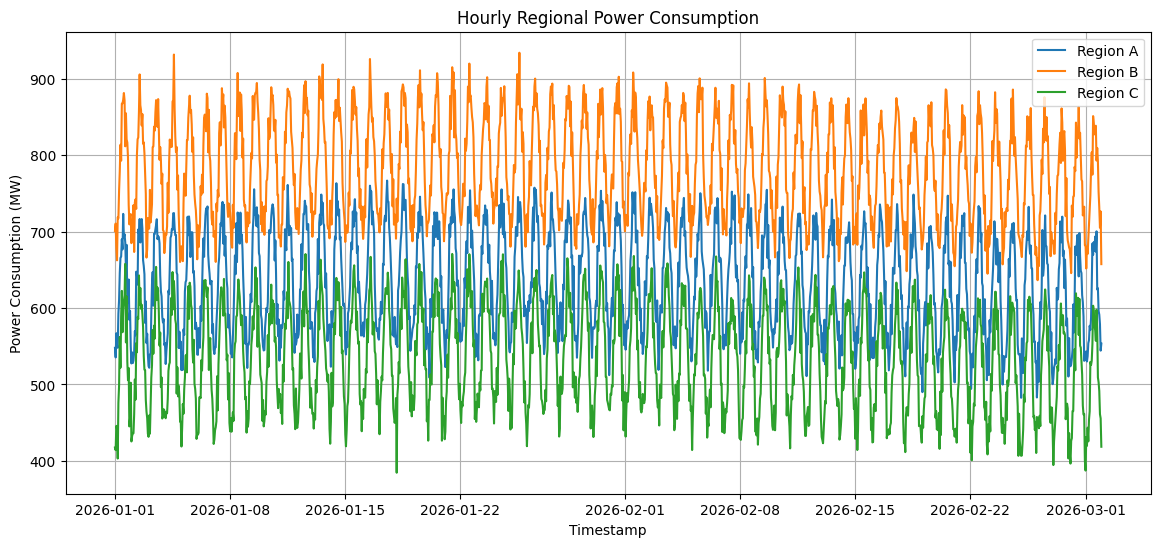

In [85]:
plt.figure(figsize=(14, 6))

for region in regions:
    region_data = data[data["region"] == region]
    plt.plot(
        region_data["timestamp"],
        region_data["power_mw"],
        label=region
    )

plt.title("Hourly Regional Power Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()

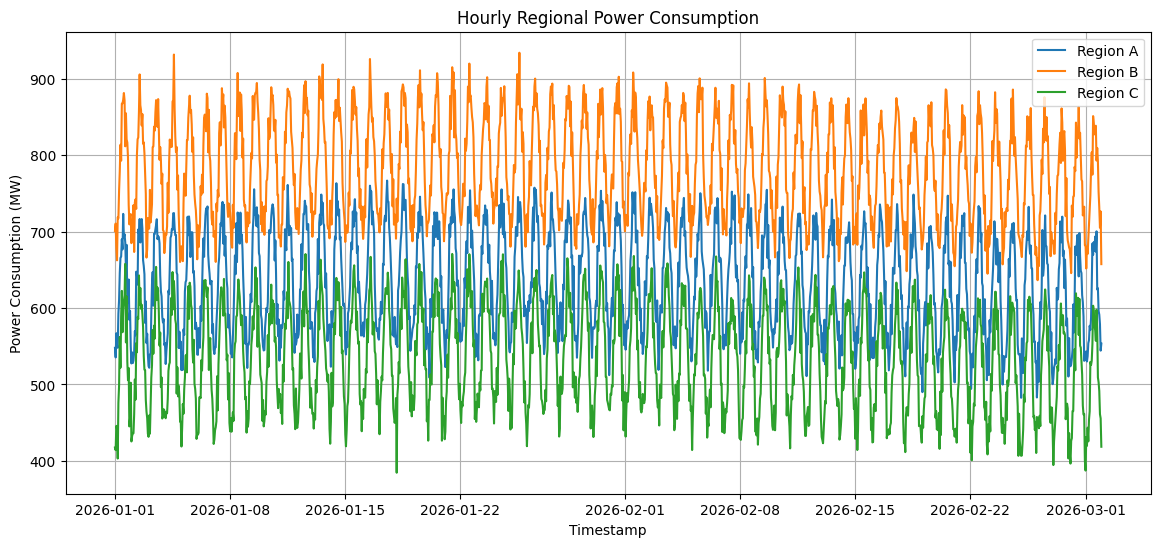

In [86]:
plt.figure(figsize=(14, 6))

for region in regions:
    region_data = data[data["region"] == region]
    plt.plot(
        region_data["timestamp"],
        region_data["power_mw"],
        label=region
    )

plt.title("Hourly Regional Power Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [87]:
data["lag_1"] = (
    data.groupby("region")["power_mw"].shift(1)
)

data["lag_2"] = (
    data.groupby("region")["power_mw"].shift(2)
)

data["lag_3"] = (
    data.groupby("region")["power_mw"].shift(3)
)

data.head(10)

,timestamp,region,temperature,base_load,power_mw,hour,day_of_week,day_of_month,month,lag_1,lag_2,lag_3
0,2026-01-01 00:00:00,Region A,23.944923,400,547.960010,0,3,1,1,NaN,NaN,NaN
1,2026-01-01 01:00:00,Region A,23.162826,400,535.397348,1,3,1,1,547.960010,NaN,NaN
2,2026-01-01 02:00:00,Region A,24.841258,400,567.034305,2,3,1,1,535.397348,547.960010,NaN
3,2026-01-01 03:00:00,Region A,26.948863,400,551.144424,3,3,1,1,567.034305,535.397348,547.960010
4,2026-01-01 04:00:00,Region A,25.348622,400,548.049916,4,3,1,1,551.144424,567.034305,535.397348
5,2026-01-01 05:00:00,Region A,26.554551,400,592.625614,5,3,1,1,548.049916,551.144424,567.034305
6,2026-01-01 06:00:00,Region A,30.568671,400,610.616345,6,3,1,1,592.625614,548.049916,551.144424
7,2026-01-01 07:00:00,Region A,30.645099,400,645.727838,7,3,1,1,610.616345,592.625614,548.049916
8,2026-01-01 08:00:00,Region A,29.995640,400,665.456662,8,3,1,1,645.727838,610.616345,592.625614
9,2026-01-01 09:00:00,Region A,32.549226,400,667.307834,9,3,1,1,665.456662,645.727838,610.616345


In [88]:
data["rolling_24"] = (
    data.groupby("region")["power_mw"]
    .transform(lambda x: x.rolling(24).mean())
)

data.head(30)

,timestamp,region,temperature,base_load,power_mw,hour,day_of_week,day_of_month,month,lag_1,lag_2,lag_3,rolling_24
0,2026-01-01 00:00:00,Region A,23.944923,400,547.960010,0,3,1,1,NaN,NaN,NaN,NaN
1,2026-01-01 01:00:00,Region A,23.162826,400,535.397348,1,3,1,1,547.960010,NaN,NaN,NaN
2,2026-01-01 02:00:00,Region A,24.841258,400,567.034305,2,3,1,1,535.397348,547.960010,NaN,NaN
3,2026-01-01 03:00:00,Region A,26.948863,400,551.144424,3,3,1,1,567.034305,535.397348,547.960010,NaN
4,2026-01-01 04:00:00,Region A,25.348622,400,548.049916,4,3,1,1,551.144424,567.034305,535.397348,NaN
5,2026-01-01 05:00:00,Region A,26.554551,400,592.625614,5,3,1,1,548.049916,551.144424,567.034305,NaN
6,2026-01-01 06:00:00,Region A,30.568671,400,610.616345,6,3,1,1,592.625614,548.049916,551.144424,NaN
7,2026-01-01 07:00:00,Region A,30.645099,400,645.727838,7,3,1,1,610.616345,592.625614,548.049916,NaN
8,2026-01-01 08:00:00,Region A,29.995640,400,665.456662,8,3,1,1,645.727838,610.616345,592.625614,NaN
9,2026-01-01 09:00:00,Region A,32.549226,400,667.307834,9,3,1,1,665.456662,645.727838,610.616345,NaN


In [89]:
data = data.dropna().reset_index(drop=True)

print("Dataset shape after feature engineering:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())

Dataset shape after feature engineering: (4251, 13)

Missing values:
timestamp       0
region          0
temperature     0
base_load       0
power_mw        0
hour            0
day_of_week     0
day_of_month    0
month           0
lag_1           0
lag_2           0
lag_3           0
rolling_24      0
dtype: int64


In [90]:
data = data.dropna().reset_index(drop=True)

print("Dataset shape after feature engineering:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())

Dataset shape after feature engineering: (4251, 13)

Missing values:
timestamp       0
region          0
temperature     0
base_load       0
power_mw        0
hour            0
day_of_week     0
day_of_month    0
month           0
lag_1           0
lag_2           0
lag_3           0
rolling_24      0
dtype: int64


In [91]:
features = [
    "temperature",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_24"
]

X = data[features]
y = data["power_mw"]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['temperature', 'hour', 'day_of_week', 'day_of_month', 'month', 'lag_1', 'lag_2', 'lag_3', 'rolling_24']

X shape: (4251, 9)
y shape: (4251,)


In [92]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3400
Testing samples: 851


In [93]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3400
Testing samples: 851


In [94]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest forecasting model trained successfully!")

Random Forest forecasting model trained successfully!


In [95]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[632.26333101 633.78213632 617.55782306 614.50965635 580.26552626
 559.22231201 532.01658738 540.15882933 479.0996741  494.88378474]


In [96]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation")
print("-------------------------")
print(f"MAE  : {mae:.2f} MW")
print(f"RMSE : {rmse:.2f} MW")

Model Evaluation
-------------------------
MAE  : 16.06 MW
RMSE : 20.32 MW


In [97]:
results = data.iloc[split_index:].copy()

results["predicted_power_mw"] = y_pred

results = results[
    [
        "timestamp",
        "region",
        "power_mw",
        "predicted_power_mw"
    ]
]

results.head(10)

,timestamp,region,power_mw,predicted_power_mw
3400,2026-01-25 13:00:00,Region C,649.116096,632.263331
3401,2026-01-25 14:00:00,Region C,633.143572,633.782136
3402,2026-01-25 15:00:00,Region C,611.597916,617.557823
3403,2026-01-25 16:00:00,Region C,597.941894,614.509656
3404,2026-01-25 17:00:00,Region C,574.117603,580.265526
3405,2026-01-25 18:00:00,Region C,565.393549,559.222312
3406,2026-01-25 19:00:00,Region C,552.966768,532.016587
3407,2026-01-25 20:00:00,Region C,519.516248,540.158829
3408,2026-01-25 21:00:00,Region C,476.599410,479.099674
3409,2026-01-25 22:00:00,Region C,504.256509,494.883785


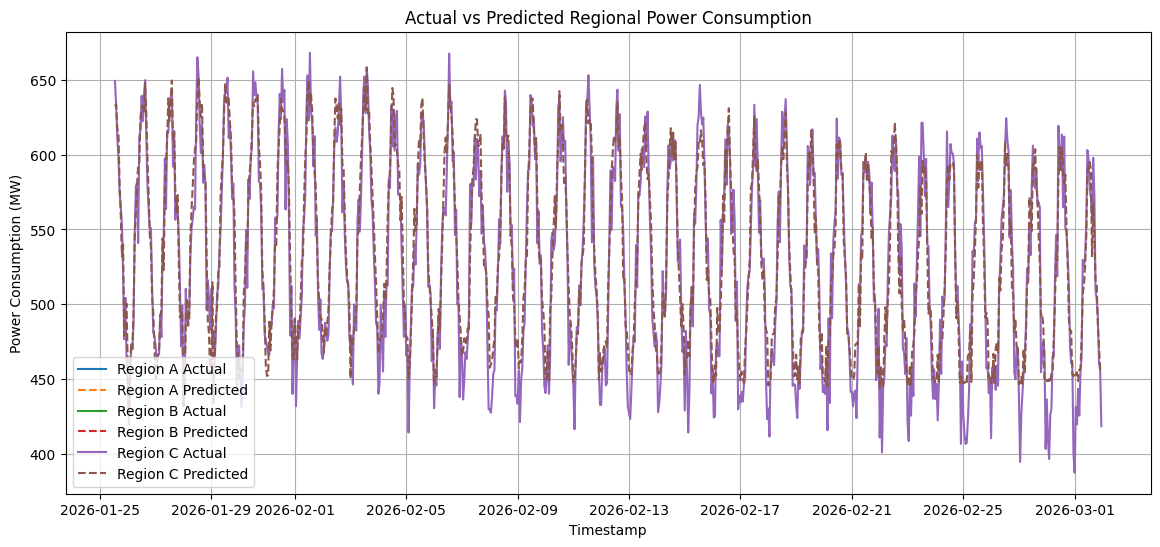

In [98]:
plt.figure(figsize=(14, 6))

for region in regions:
    region_results = results[
        results["region"] == region
    ]

    plt.plot(
        region_results["timestamp"],
        region_results["power_mw"],
        label=f"{region} Actual"
    )

    plt.plot(
        region_results["timestamp"],
        region_results["predicted_power_mw"],
        linestyle="--",
        label=f"{region} Predicted"
    )

plt.title("Actual vs Predicted Regional Power Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
def identify_intent(text):
    text = text.lower()

    if "forecast" in text or "predict" in text:
        return "POWER_FORECAST"

    elif "temperature" in text:
        return "TEMPERATURE"

    elif "power" in text or "consumption" in text:
        return "POWER_USAGE"

    elif "alert" in text or "threshold" in text:
        return "ALERT"

    else:
        return "UNKNOWN"

In [100]:
def extract_region(text):
    text = text.lower()

    for region in regions:
        if region.lower() in text:
            return region

    return None

In [101]:
query = "What is the power consumption in Region A?"

intent = identify_intent(query)
region = extract_region(query)

print("Query:", query)
print("Intent:", intent)
print("Region:", region)

Query: What is the power consumption in Region A?
Intent: POWER_USAGE
Region: Region A


In [102]:
query = "What is the power forecast for Region B?"

intent = identify_intent(query)
region = extract_region(query)

print("Query:", query)
print("Intent:", intent)
print("Region:", region)

Query: What is the power forecast for Region B?
Intent: POWER_FORECAST
Region: Region B


In [103]:
def process_query(query):
    intent = identify_intent(query)
    region = extract_region(query)

    if region is None:
        return "Please specify a region."

    if intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"Latest power consumption in {region} is "
            f"{latest['power_mw']:.2f} MW."
        )

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"Latest temperature in {region} is "
            f"{latest['temperature']:.2f} °C."
        )

    elif intent == "POWER_FORECAST":

        region_results = results[
            results["region"] == region
        ]

        latest_prediction = region_results.iloc[-1]

        return (
            f"Predicted power consumption for {region} is "
            f"{latest_prediction['predicted_power_mw']:.2f} MW."
        )

    else:
        return "Sorry, I could not understand the query."

In [104]:
queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "What is the power forecast for Region C?"
]

for query in queries:
    print("Query:", query)
    print("Response:", process_query(query))
    print("-" * 60)

Query: What is the power consumption in Region A?
Response: Latest power consumption in Region A is 553.46 MW.
------------------------------------------------------------
Query: What is the temperature in Region B?
Response: Latest temperature in Region B is 20.62 °C.
------------------------------------------------------------
Query: What is the power forecast for Region C?
Response: Predicted power consumption for Region C is 456.40 MW.
------------------------------------------------------------


# Day 1 Summary

## Completed Tasks

- Generated hourly regional power telemetry data for three regions.
- Added temperature and time-based features.
- Created lag and 24-hour rolling-average features.
- Developed a Random Forest model for power-consumption forecasting.
- Evaluated the model using MAE and RMSE.
- Compared actual and predicted power consumption.
- Defined an initial natural-language telemetry query workflow.
- Implemented basic intent and region identification.
- Tested power consumption, temperature, and forecast queries.

## Day 1 Outcome

The initial forecasting model successfully predicts regional power consumption from historical telemetry and related features. A basic natural-language workflow was also established to identify operator queries and provide telemetry or forecast responses.

## Status

**Day 1 Completed**